In [1]:
import pandas as pd
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve
)
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Versions and updated datasets/model_v2_feas.csv')

In [3]:
num_cols_to_fill = ['transaction_amount', 'time_day', 'time_diff_log']
for col in num_cols_to_fill:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
cat_cols_to_fill = [col for col in df.columns if col not in num_cols_to_fill]
for col in cat_cols_to_fill:
    df[col] = df[col].astype(str)

In [4]:
main = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Versions and updated datasets/Fraud_Data.csv')
v4 = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Versions and updated datasets/model_v4.csv')
df['amt_log'] = v4['amt_log']
df['time_diff_bins'] = pd.cut(df['time_diff_log'], bins=20, include_lowest=True).astype(object)
df['card_type_user_os'] = v4['card_type_user_os']
df['card_network'] = main['card_network']

In [5]:
label = df['is_fraud'].astype(int)
predictors = df.drop(columns=['is_fraud'])
x_train, x_test, y_train, y_test = train_test_split(
    predictors, label, test_size=0.2, random_state=42, stratify=label
)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)
print(y_train.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64


In [6]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_amount       471129 non-null  float64
 1   card_type                471129 non-null  object 
 2   purchaser_email_domain   471129 non-null  object 
 3   device_type              471129 non-null  object 
 4   is_identity_seen_before  471129 non-null  object 
 5   user_os                  471129 non-null  object 
 6   user_browser             471129 non-null  object 
 7   environment_risk         471129 non-null  object 
 8   card_info                471129 non-null  object 
 9   time_hour                471129 non-null  object 
 10  time_day                 471129 non-null  float64
 11  amt_bins                 471129 non-null  object 
 12  day_of_week              471129 non-null  object 
 13  time_diff_log            471129 non-null  float64
 14  amt_l

In [7]:
num_cols    = ['amt_log', 'time_diff_log']
target_cols = ['purchaser_email_domain']
cat_cols    = [col for col in x_train.columns if col not in num_cols + target_cols]

In [13]:
for col in cat_cols:
    print('----------------------')
    print(col)
    print("NaNs:", x_train[col].isna().sum())
    print("Unique:", x_train[col].unique())

----------------------
transaction_amount
NaNs: 0
Unique: [117.     58.95   29.818 ... 103.17  749.19  423.13 ]
----------------------
card_type
NaNs: 0
Unique: ['debit' 'credit']
----------------------
device_type
NaNs: 0
Unique: ['nan' 'mobile' 'desktop']
----------------------
is_identity_seen_before
NaNs: 0
Unique: ['nan' 'New' 'Found']
----------------------
user_os
NaNs: 0
Unique: ['nan' 'Other' 'Android' 'Windows' 'iOS' 'macOS' 'Linux']
----------------------
user_browser
NaNs: 0
Unique: ['nan' 'Chrome' 'Other' 'IE' 'Firefox' 'Safari' 'Opera' 'Edge' 'Samsung'
 'Android WebView']
----------------------
environment_risk
NaNs: 0
Unique: ['nan' '0.0' '1.0' '2.0']
----------------------
card_info
NaNs: 0
Unique: ['mastercard_debit' 'visa_debit' 'visa_credit' 'discover_debit'
 'mastercard_credit' 'american express_credit' 'discover_credit'
 'american express_debit']
----------------------
time_hour
NaNs: 0
Unique: ['4' '13' '3' '17' '16' '21' '2' '22' '23' '0' '20' '18' '7' '15' '14'


In [8]:
# # Logistic Regression needs scaling on numeric cols
# num_pipeline = Pipeline([
#     ('scaler', StandardScaler())
# ])
# cat_pipeline = Pipeline([
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])
# target_pipeline = Pipeline([
#     ('target', TargetEncoder(smoothing=10, handle_unknown='value'))
# ])
# preprocessor = ColumnTransformer([
#     ('num',    num_pipeline,    num_cols),
#     ('target', target_pipeline, target_cols),
#     ('cat',    cat_pipeline,    cat_cols)
# ])

# neg = int((y_train == 0).sum())
# pos = int((y_train == 1).sum())
# print(f"neg={neg:,}  pos={pos:,}  ratio={neg/pos:.1f}")

# # class_weight='balanced' is logistic regression's version of scale_pos_weight
# model = LogisticRegression(
#     C             = 0.1,           # regularisation (lower = stronger penalty)
#     class_weight  = 'balanced',    # handles fraud imbalance
#     solver        = 'saga',        # best solver for large datasets
#     max_iter      = 1000,
#     random_state  = 42,
#     n_jobs        = -1
# )

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', model)
# ])
# print("Pipeline ready ✓")

In [9]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cv_predict = cross_val_predict(final_pipe, x_train, y_train, cv=cv, n_jobs=-1)
# joblib.dump(cv_predict, 'cv_predict_lr.pkl')
# print("cv_predict saved ✓", cv_predict.shape)

# cv_proba = cross_val_predict(final_pipe, x_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
# joblib.dump(cv_proba, 'cv_proba_lr.pkl')
# print("cv_proba saved ✓", cv_proba.shape)

In [10]:
# final_pipe.fit(x_train, y_train)
# joblib.dump(final_pipe, 'model_lr.pkl')
# print("Model saved ✓")

In [11]:
cv_predict = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_predict_v4_lr.pkl')
cv_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/cv_proba_v4_lr.pkl')
model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/model_v4_lr.pkl')
# model = final_pipe

In [12]:
lr_test  = model.predict_proba(x_test)[:, 1]
joblib.dump(lr_test, '/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/lr_proba_test.pkl')

['/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/v4/lr_proba_test.pkl']

In [13]:
print(f"Precision : {precision_score(y_train, cv_predict) * 100:.2f}%")
print(f"Recall    : {recall_score(y_train, cv_predict) * 100:.2f}%")
print()
print(classification_report(y_train, cv_predict))

Precision : 8.74%
Recall    : 62.66%

              precision    recall  f1-score   support

           0       0.98      0.76      0.86    454631
           1       0.09      0.63      0.15     16498

    accuracy                           0.76    471129
   macro avg       0.53      0.69      0.51    471129
weighted avg       0.95      0.76      0.83    471129



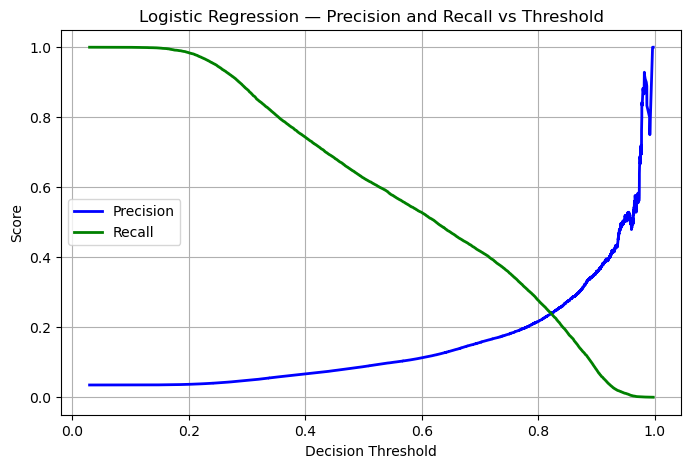

In [14]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_train, cv_proba)
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression — Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
x_train.dtypes

transaction_amount         float64
card_type                   object
purchaser_email_domain      object
device_type                 object
is_identity_seen_before     object
user_os                     object
user_browser                object
environment_risk            object
card_info                   object
time_hour                   object
time_day                   float64
amt_bins                    object
day_of_week                 object
time_diff_log              float64
amt_log                    float64
time_diff_bins              object
card_type_user_os           object
card_network                object
dtype: object

In [16]:
fraud_probs = model.predict_proba(x_train)[y_train == 1, 1]
print('fraud_porbs done')
nonfraud_probs = model.predict_proba(x_train)[y_train == 0, 1]
print('fraud_porbs done')

fraud_porbs done
fraud_porbs done


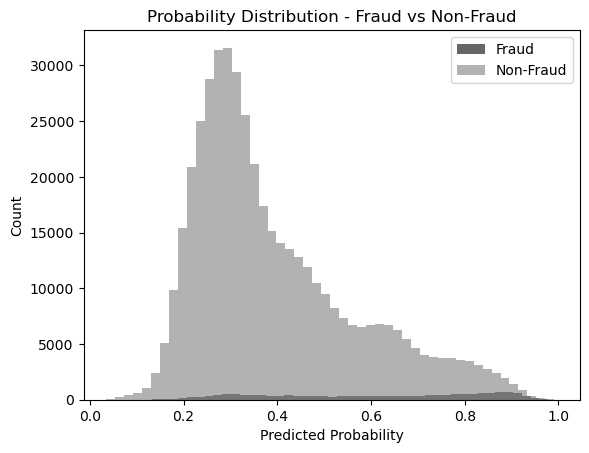

In [17]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
# plt.ylim(0, 5000)
plt.show()

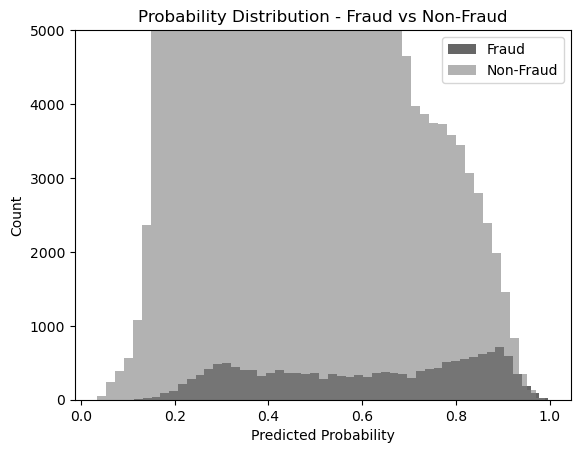

In [18]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 5000)
plt.show()

In [19]:
print(f"Fraud Mean:      {fraud_probs.mean():.4f}")
print(f"Non-Fraud Mean:  {nonfraud_probs.mean():.4f}")
print(f"Gap:             {(fraud_probs.mean() - nonfraud_probs.mean()):.4f}")
print(f"Fraud Max:       {fraud_probs.max():.4f}")
print(f"Non Fraud min: {nonfraud_probs.min():.4f}")
print(f"Fraud Std:         {fraud_probs.std():.4f}")
print(f"Non-Fraud Std:     {nonfraud_probs.std():.4f}")``

SyntaxError: invalid syntax (2836201033.py, line 7)